In [1]:
import polars as pl
import joblib
from pathlib import Path
from glob import glob
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Point to the data/ directory at repo root (download S3 data there)
DATA_DIR = Path('../data')

MANUSCRIPT_FIG_DIR = Path('../manuscript/figures')
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
site_mapping = {
    'bidmc':'BIDMC',
    'stan':'Stanford',
    'emory':'Emory',
    'bch':'BCH',
    'mgb':'MGB',
}
model_type_mapping = {
    'nt1':'NT1',
    'nt2ih':'NT2/IH',
    'nt12':'NT1/2/IH',
    'result_label':'NT1'
}

In [3]:
def plot_confusion_matrices(models, feat, site_mapping, model_type, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    if model_type == 'nt1':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 1).then(1).otherwise(0).alias('nt1')
        )
    elif model_type == 'nt2ih':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 2).then(1).otherwise(0).alias('nt2ih')
        )

    for idx, k in enumerate(sorted(models.keys())):
        sub_feat = feat.filter(
            pl.col('cohort') == k # test site
        )
        for c in ['annot','cohort','id','date']:
            if c in sub_feat.columns and c != model_type:
                sub_feat = sub_feat.drop(c)
        X = sub_feat.drop(model_type)
        y = sub_feat[model_type]
        
        y_pred = models[k].predict(X)
        cm = confusion_matrix(y, y_pred)
        
        # Calculate percentages
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        # Create custom annotations with percentage and counts
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f'{cm_percent[i, j]:.1f}%\n({cm[i, j]})'
        
        sns.heatmap(cm_percent, annot=annot, fmt='', cmap='Blues', ax=axes[idx], 
                    vmin=0, vmax=100, cbar=False, annot_kws={'fontsize': 14})
        axes[idx].set_title(f'Test Site: {site_mapping[k]}', fontsize=16)
        axes[idx].set_xlabel('Predicted label', fontsize=14)
        axes[idx].set_ylabel('True label', fontsize=14)
        axes[idx].tick_params(axis='both', labelsize=12)

    # Hide the extra subplot
    axes[-1].axis('off')

    # Add colorbar in the unused subplot
    cbar = fig.colorbar(axes[0].collections[0], ax=axes[-1], fraction=0.8)
    cbar.set_label('Percentage (%)', fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    fig.suptitle(f'{model_type_mapping[model_type]} Confusion Matrices', fontsize=20, y=1.02)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')

    plt.show()

In [4]:
features = pl.read_parquet(DATA_DIR / 'discriminative-modeling/features.parquet').hstack(
    pl.read_parquet(DATA_DIR / 'discriminative-modeling/notes.parquet').select('annot', 'cohort')
).filter(
    pl.col('annot') != 3 # unsure cases
).select(
    'id','date','cohort','annot', pl.all().exclude(['id','date','cohort','annot'])
)

In [5]:
features

id,date,cohort,annot,^347\.?[0|1]1|^G47\.?4[1|2]1,^347\.?[0|1]0|^G47\.?4[1|2]9,^G47\.?1|^780\.?5[3|4],adderall,ambien,clomipramine,concerta,cymbalta,dexedrine,dextroamphetamine,duloxetine,effexor,fluoxetine,imipramine,modafinil,nuvigil,paroxetine,pitolisant,protriptyline,provigil,prozac,ritalin,sertraline,sodium oxybate,solriamfetol,sunosi,venlafaxine,wakix,xyrem,xywav,50 improv_,abnorm_,abnorm find_,…,type_neg_,type walk_neg_,unrefresh_neg_,unrefresh sleep_neg_,use_neg_,venlafaxin_neg_,visit_neg_,vivid_neg_,vivid dream_neg_,wake_neg_,wake test_neg_,walk_neg_,walk 30_neg_,walk activ_neg_,walk q_neg_,watch_neg_,watch diet_neg_,weak_neg_,wean_neg_,week_neg_,weight_neg_,weight decreas_neg_,weight discuss_neg_,weight gain_neg_,weight increas_neg_,weight loss_neg_,weight mainten_neg_,weight manag_neg_,work_neg_,work diet_neg_,work routin_neg_,worri_neg_,xr_neg_,xyrem_neg_,yes_neg_,zanaflex_neg_,zoloft_neg_
str,date,str,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""150041900""",2017-09-27,"""bidmc""",2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,…,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""150012174""",2019-03-04,"""bidmc""",2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
"""179002121""",2022-12-25,"""emory""",4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""179017431""",2021-11-19,"""emory""",4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""177519609""",2017-02-27,"""stan""",4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,1,1,1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""117173180""",2024-02-14,"""mgb""",4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""177523807""",2021-06-25,"""stan""",1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
"""179000770""",2016-06-13,"""emory""",2,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,…,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [6]:
# Load all your models
rf_models = {}
xgb_models = {}
gb_models = {} 
lr_models = {}

results_dir = DATA_DIR / 'results/nt1_vs_others'

for m in glob(str(results_dir / 'fold_models_GradientBoosting/*.pkl')):
    gb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

for m in glob(str(results_dir / 'fold_models_RandomForest/*.pkl')):
    rf_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

for m in glob(str(results_dir / 'fold_models_XGBoost/*.pkl')):
    xgb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

for m in glob(str(results_dir / 'fold_models_LogisticRegression/*.pkl')):
    lr_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

# Compare all three
model_comparison = {
    'GradientBoosting': gb_models,
    'RandomForest': rf_models,
    'XGBoost': xgb_models,
    'LogisticRegression': lr_models
}

/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lea

/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/pickle.py:1835: UserWarning: [17:15:05] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Plotting confusion matrices for GradientBoosting...


Saved: ../manuscript/figures/efigure3_nt1_confusion_matrices.png


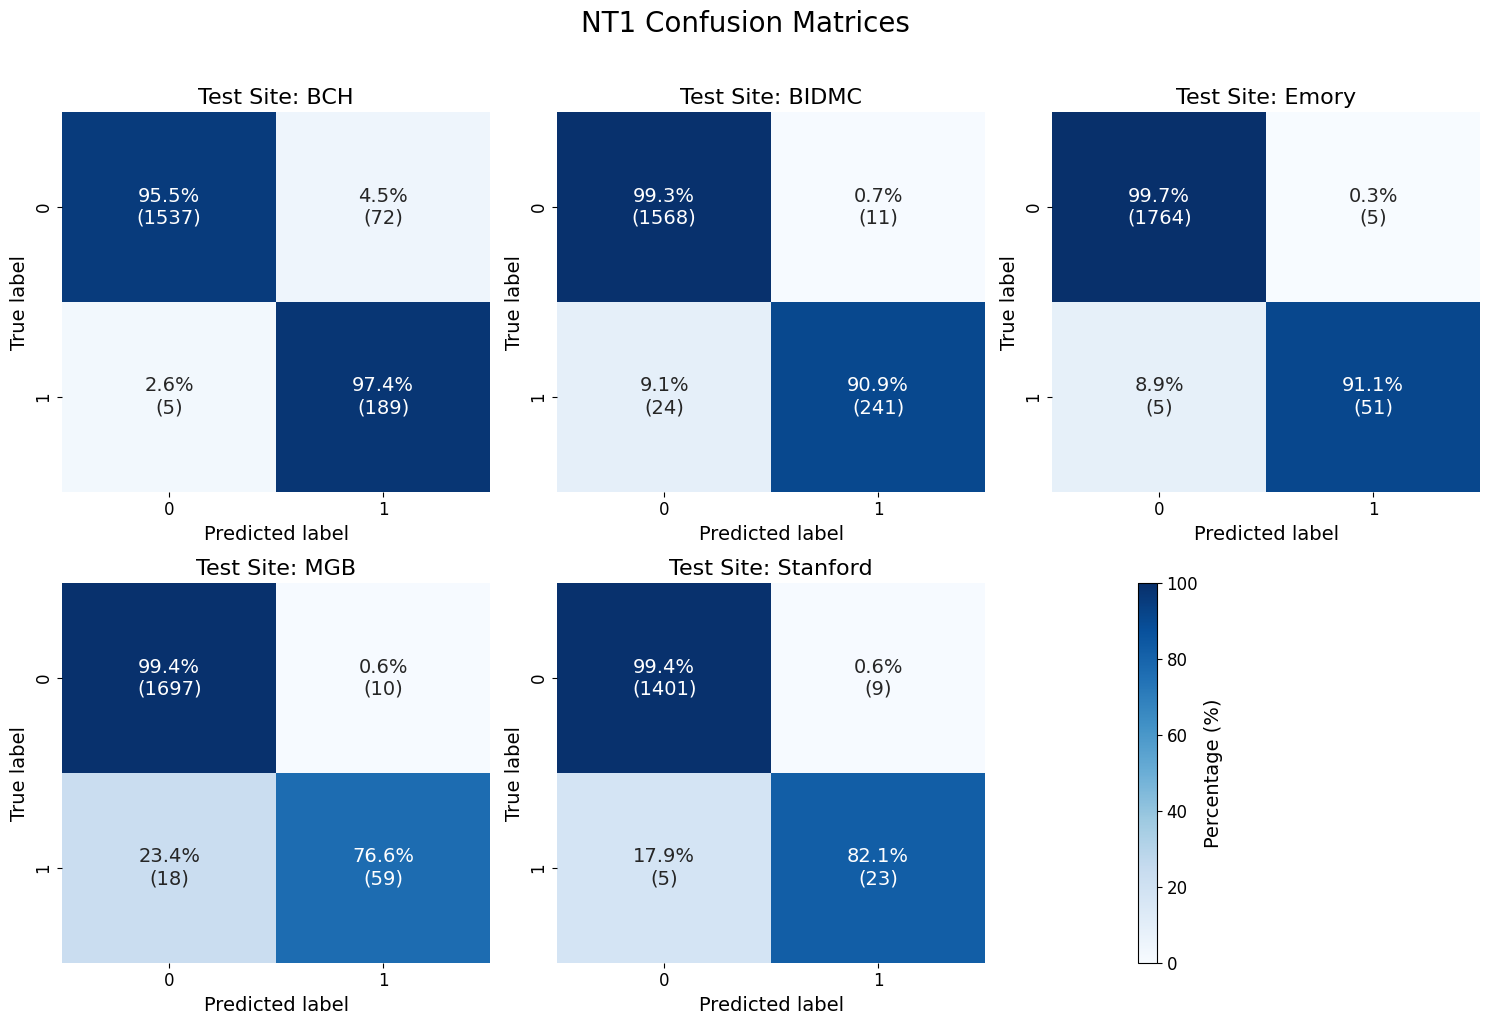

Plotting confusion matrices for RandomForest...


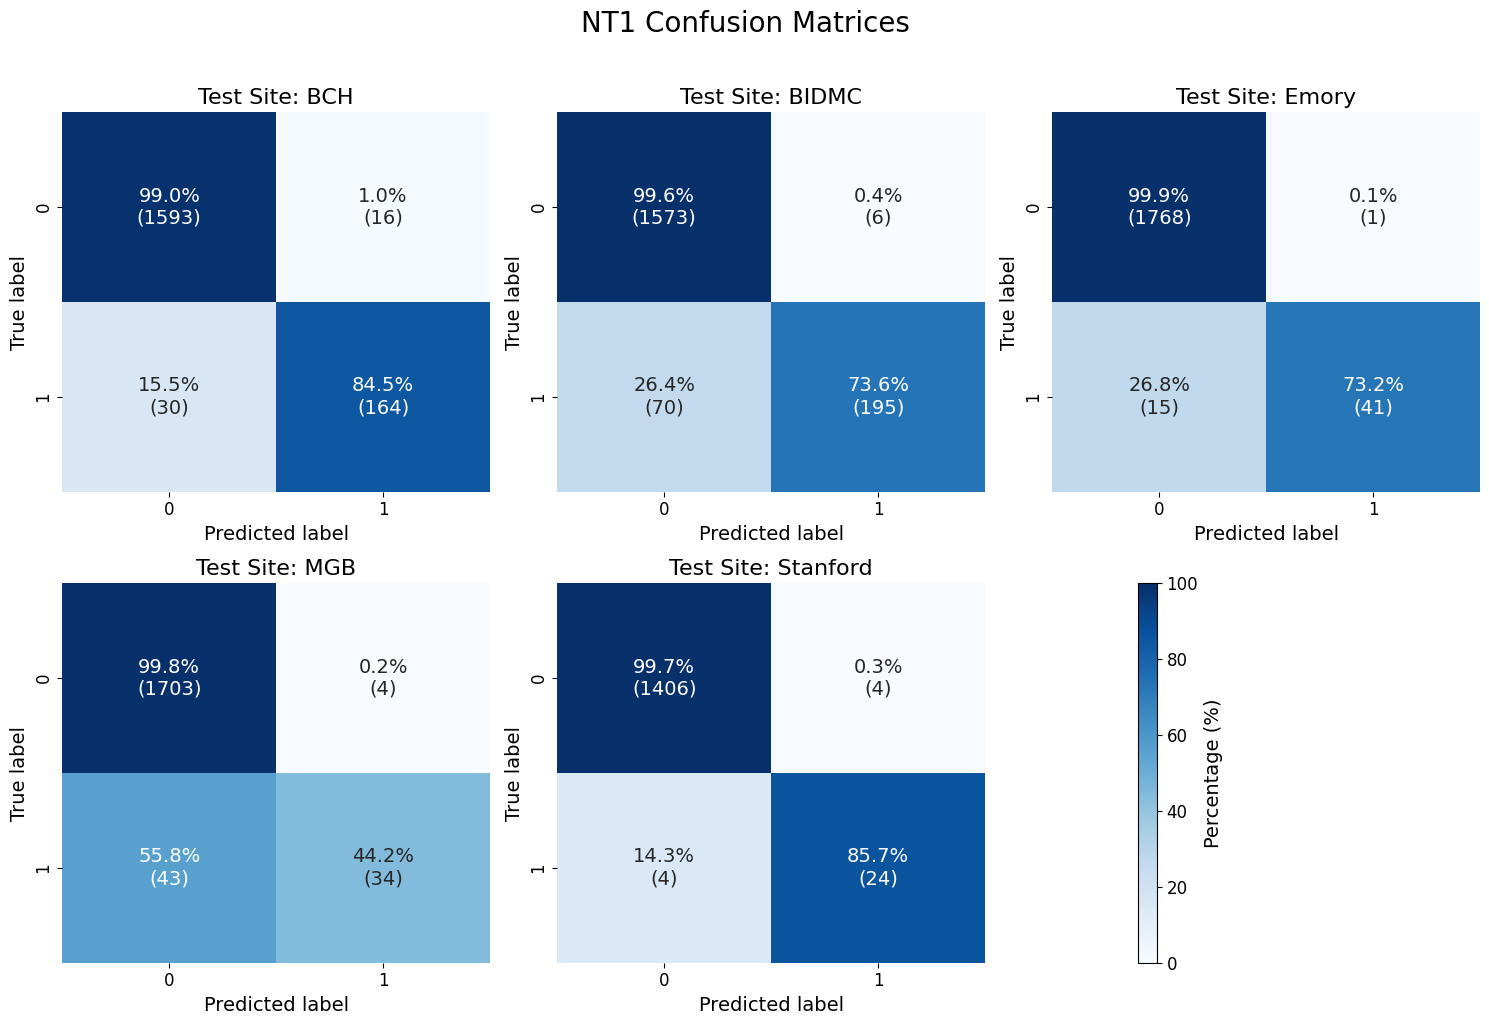

Plotting confusion matrices for XGBoost...


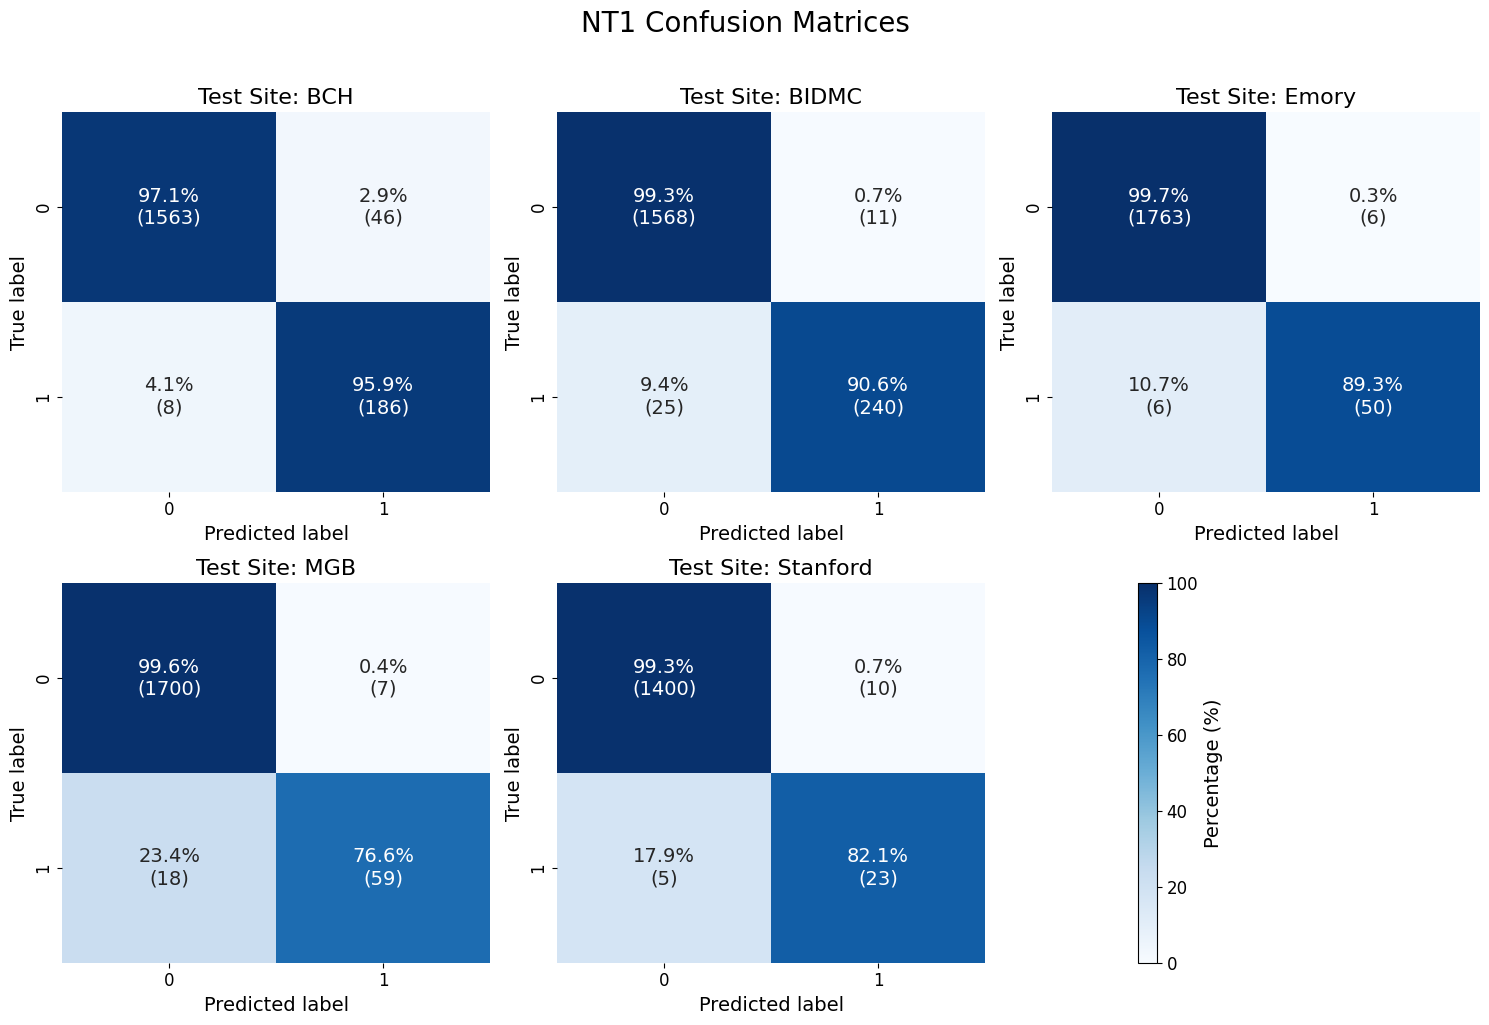

Plotting confusion matrices for LogisticRegression...


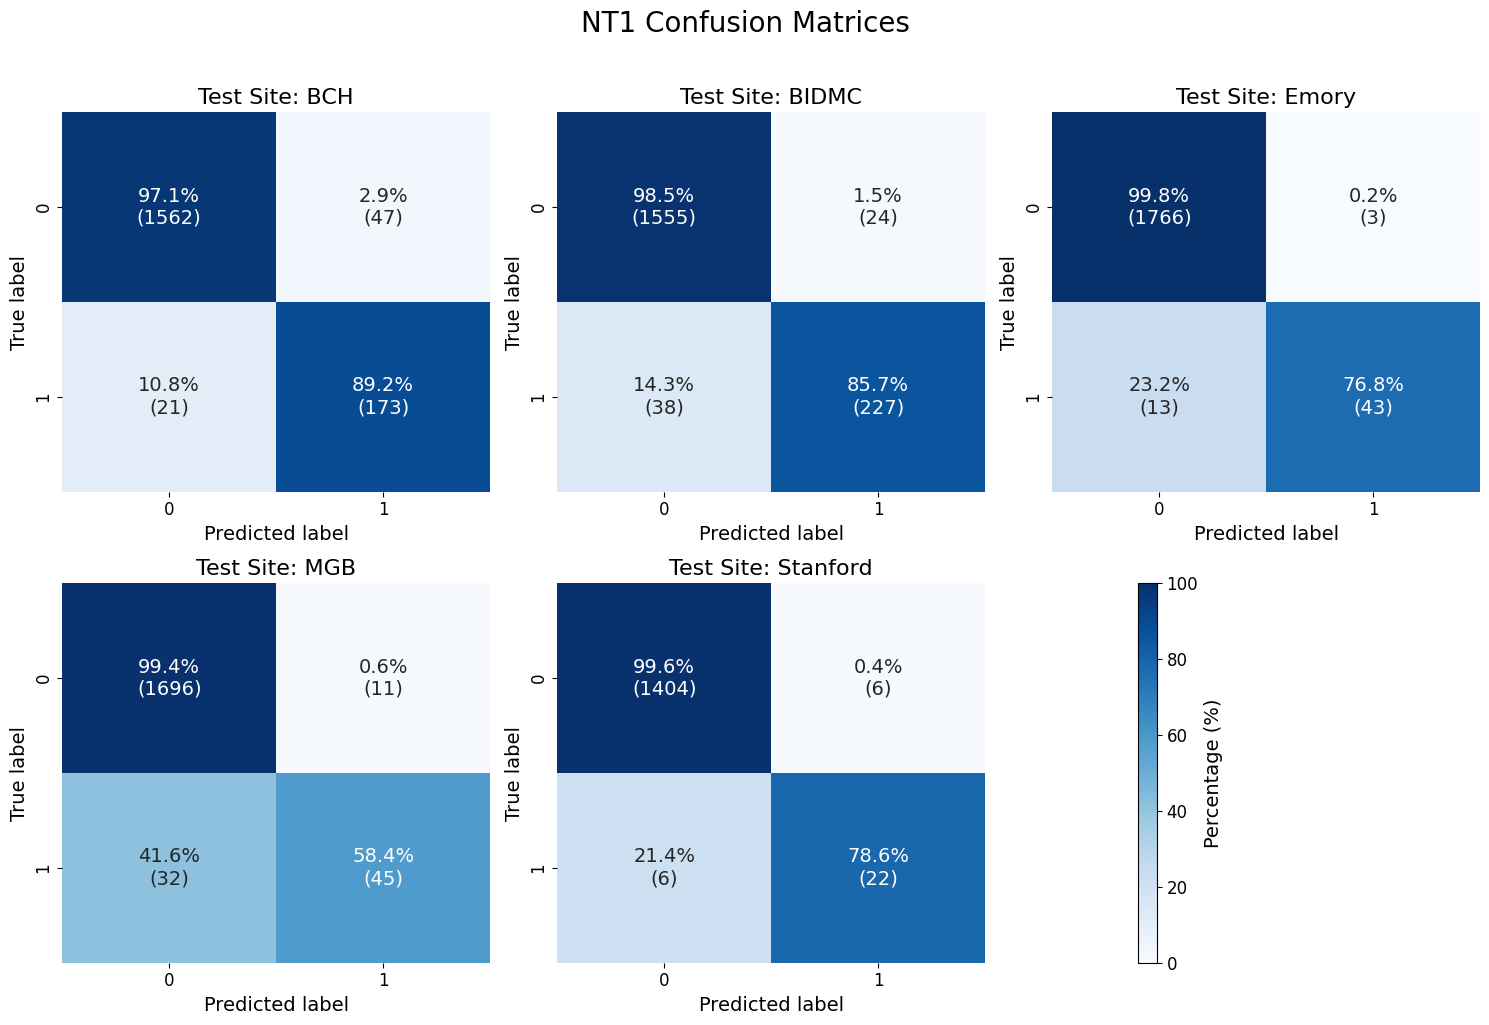

In [7]:
# Best NT1 model is GradientBoosting (eFigure 3)
for model_name, models in model_comparison.items():
    save_path = None
    if model_name == 'GradientBoosting':
        save_path = MANUSCRIPT_FIG_DIR / 'efigure3_nt1_confusion_matrices.png'
    print(f'Plotting confusion matrices for {model_name}...')
    plot_confusion_matrices(models, features, site_mapping, 'nt1', save_path=save_path)

In [8]:
# Load all your models
rf_models = {}
xgb_models = {}
gb_models = {} 
lr_models = {}

results_dir = DATA_DIR / 'results/nt2ih_vs_others'

for m in glob(str(results_dir / 'fold_models_GradientBoosting/*.pkl')):
    gb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

for m in glob(str(results_dir / 'fold_models_RandomForest/*.pkl')):
    rf_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

for m in glob(str(results_dir / 'fold_models_XGBoost/*.pkl')):
    xgb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

for m in glob(str(results_dir / 'fold_models_LogisticRegression/*.pkl')):
    lr_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

# Compare all three
model_comparison = {
    'GradientBoosting': gb_models,
    'RandomForest': rf_models,
    'XGBoost': xgb_models,
    'LogisticRegression': lr_models
}

/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lea

Plotting confusion matrices for GradientBoosting...


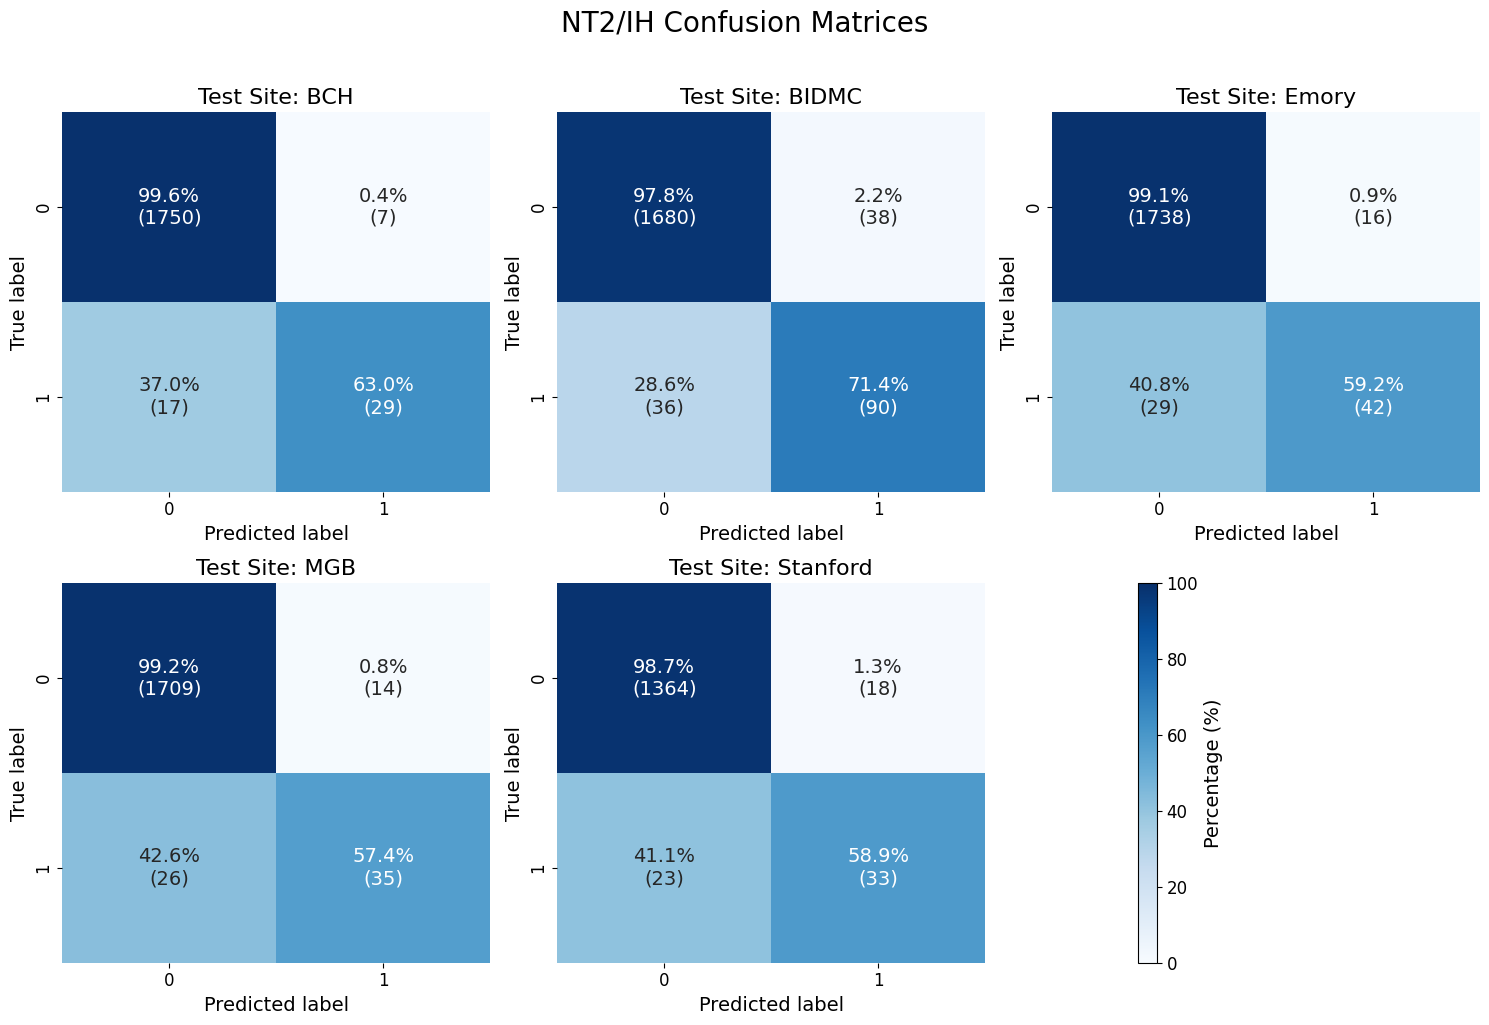

Plotting confusion matrices for RandomForest...


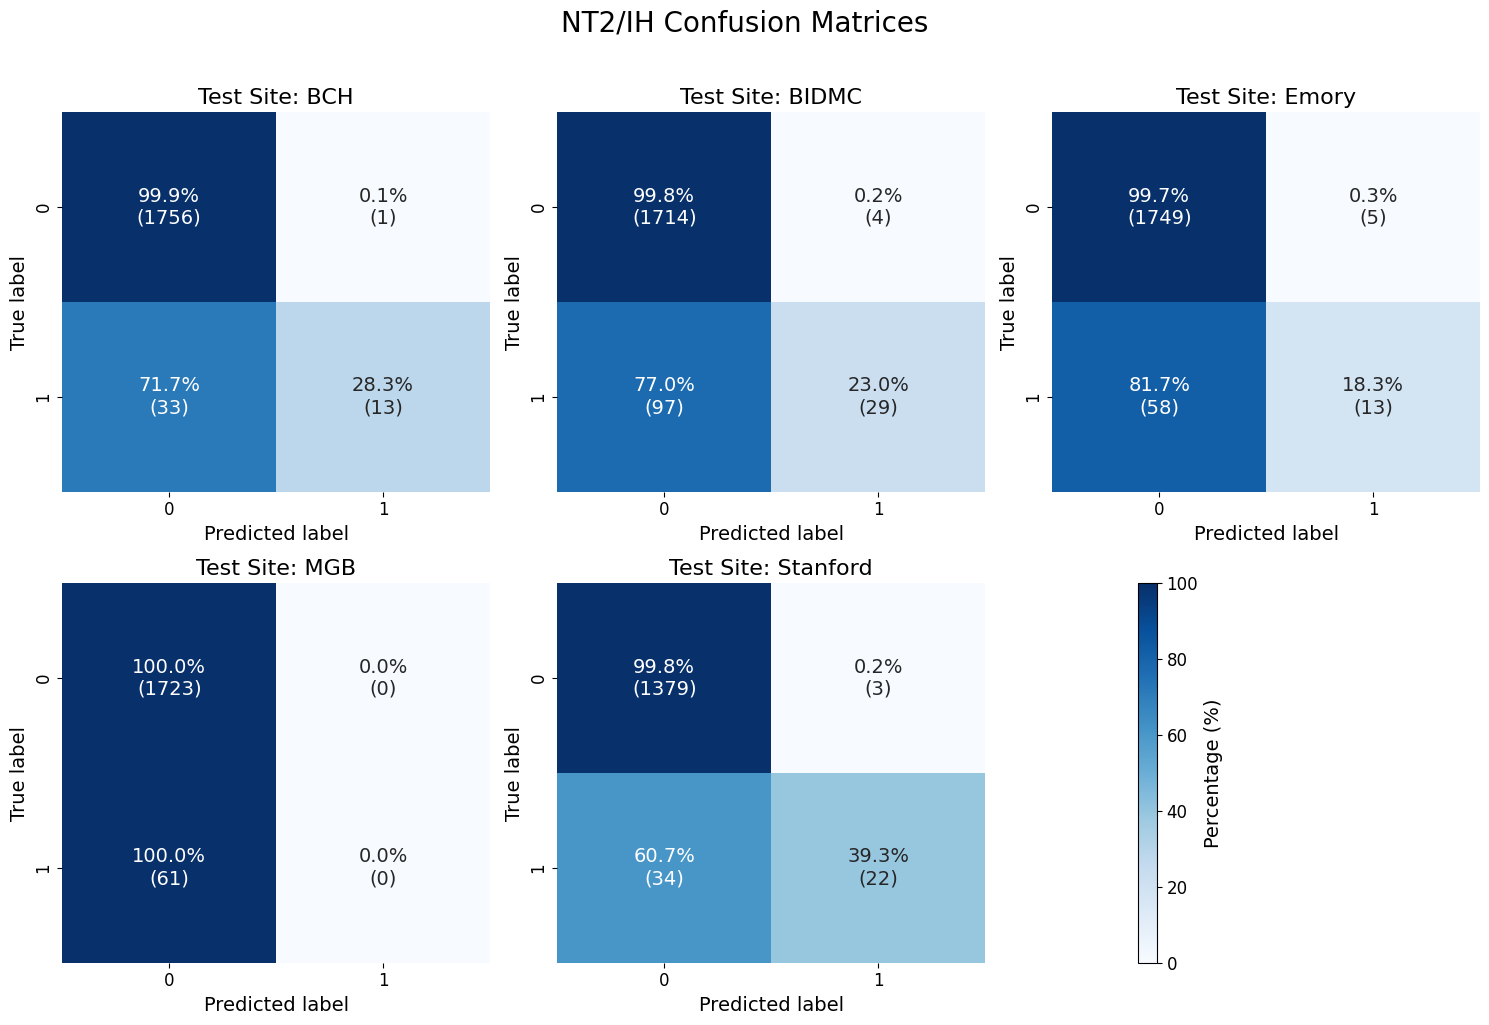

Plotting confusion matrices for XGBoost...


Saved: ../manuscript/figures/efigure4_nt2ih_confusion_matrices.png


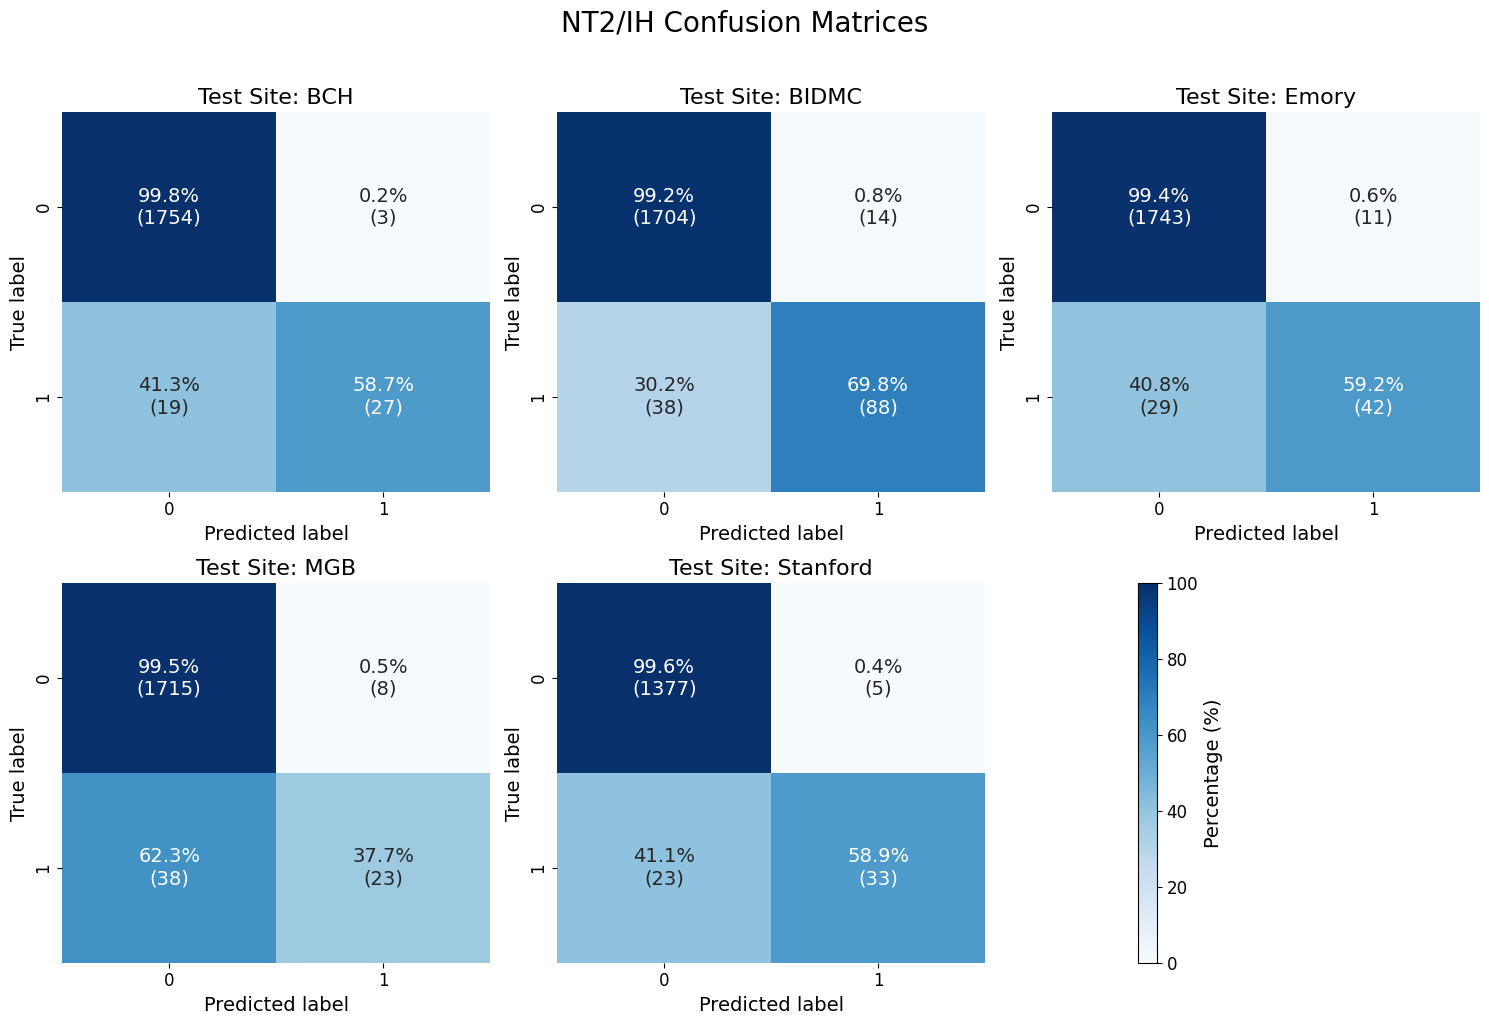

Plotting confusion matrices for LogisticRegression...


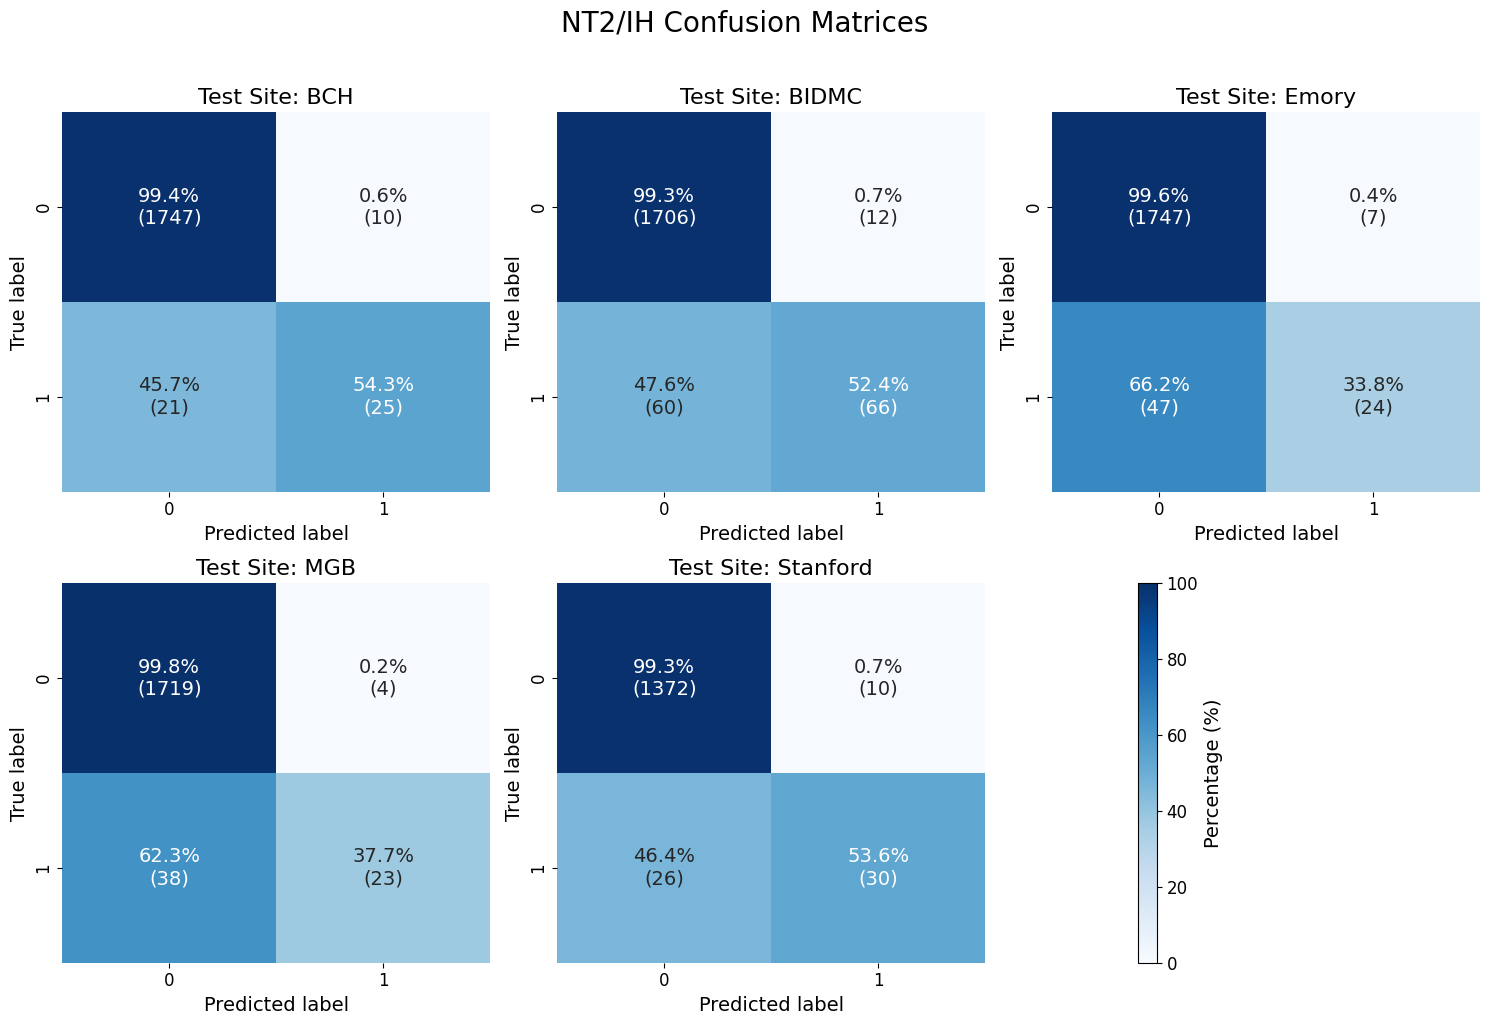

In [9]:
# Best NT2/IH model is XGBoost (eFigure 4)
for model_name, models in model_comparison.items():
    save_path = None
    if model_name == 'XGBoost':
        save_path = MANUSCRIPT_FIG_DIR / 'efigure4_nt2ih_confusion_matrices.png'
    print(f'Plotting confusion matrices for {model_name}...')
    plot_confusion_matrices(models, features, site_mapping, 'nt2ih', save_path=save_path)